<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/Expt6_LSTM_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPT NO: 6 — IMPLEMENTATION OF LONG SHORT-TERM MEMORY (LSTM) FOR SENTIMENT ANALYSIS

**Name:** Swasthika M  **Roll No:** 24BAD121  **Date:**09.10.2026

**Aim:** To implement an LSTM neural network for sentiment analysis and classify text into Positive / Negative sentiment.


## PART A: DATASET PREPARATION

In [18]:
# ====== Setup ======

print("SWASTHIKA M 24BAD121")

import re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)

SWASTHIKA M 24BAD121
TensorFlow version: 2.21.0


In [29]:
# ====== Load IMDB dataset (50,000 labelled reviews) ======
(x_train_int, y_train_all), (x_test_int, y_test) = imdb.load_data()   # integer-encoded by Keras
word_index = imdb.get_word_index()

# Keras reserves indices 0-3, real words start at 3 (+3 offset)
index_word = {v + 3: k for k, v in word_index.items()}

def decode_review(seq):
    return " ".join(index_word.get(i, "") for i in seq if i > 3)

# Convert back to raw text so we can do our own preprocessing + tokenization
train_texts_all = [decode_review(s) for s in x_train_int]
test_texts      = [decode_review(s) for s in x_test_int]


print("Training reviews:", len(train_texts_all), "| Test reviews:", len(test_texts))

Training reviews: 25000 | Test reviews: 25000



Label: Positive
one of the great things about many of the superb chinese movies you can find if you are lucky in the video stores is they are very accurate retellings of actual true stories farewell my concubine the emperor and the assassin and this movie are perfect examples the film makers take a true story and w ...

Label: Positive
this was usually producer alexander korda's advice on set to many of his underlings the film is credited with three directors but in truth alex zoltan korda and william cameron menzies helped out pushing it to six br br for john kobal's 1987 book the top 100 movies his survey of 81 film critics saw  ...

Label: Positive
centered in the downtown and out skirts of detroit this comedy i found to be a terrific new comedic duo 'noriyuki pat morita' is a very funny man who happens to be a cop from japan on the trail of an industrial secrets thief who has stolen a 'proto type' turbo super charger reluctantly he goes to th ...

Class distribution (train): {np.i

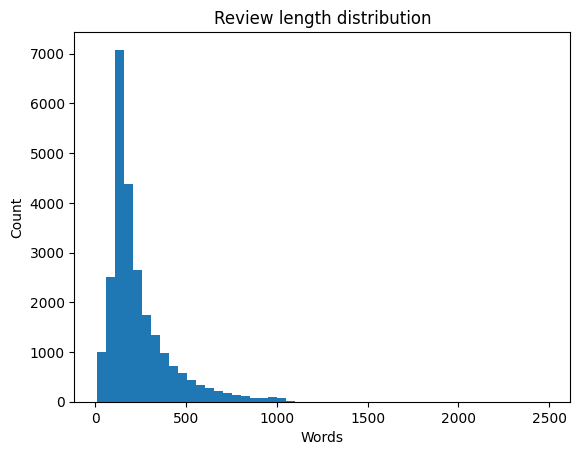

In [19]:
# ====== Explore dataset ======

label_name = {0: "Negative", 1: "Positive"}

for i in random.sample(range(len(train_texts_all)), 3):
    print(f"\nLabel: {label_name[y_train_all[i]]}")
    print(train_texts_all[i][:300], "...")

print("\nClass distribution (train):", dict(zip(*np.unique(y_train_all, return_counts=True))))
print("Classes: 0 = Negative, 1 = Positive")

lengths = [len(t.split()) for t in train_texts_all]
print("Average review length:", int(np.mean(lengths)), "words | Max:", max(lengths))
plt.hist(lengths, bins=50); plt.title("Review length distribution"); plt.xlabel("Words"); plt.ylabel("Count"); plt.show()

In [20]:
# ====== Text preprocessing + tokenization ======
def clean_text(text):
    text = text.lower()                                # lowercase
    text = re.sub(r"<br\s*/?>", " ", text)             # remove HTML line breaks
    text = re.sub(r"[^a-z\s']", " ", text)             # remove symbols / digits
    text = re.sub(r"\s+", " ", text).strip()           # collapse spaces
    return text

def tokenize(text):
    return clean_text(text).split()

train_tokens_all = [tokenize(t) for t in train_texts_all]
test_tokens      = [tokenize(t) for t in test_texts]

print("Sample tokens:", train_tokens_all[0][:15])

Sample tokens: ['this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', "everyone's", 'really', 'suited', 'the', 'part']


In [21]:
# ====== Build vocabulary (from training data only) ======
VOCAB_SIZE = 10000          # keep the 10,000 most frequent words
MAX_LEN    = 200            # padded sequence length
PAD, UNK   = 0, 1           # special indices

counter = Counter(w for toks in train_tokens_all for w in toks)
most_common = [w for w, _ in counter.most_common(VOCAB_SIZE - 2)]
vocab = {"<PAD>": PAD, "<UNK>": UNK}
for i, w in enumerate(most_common, start=2):
    vocab[w] = i

print("Vocabulary size:", len(vocab))
print("First 10 vocab entries:", list(vocab.items())[:10])

# ====== Tokens -> integer sequences ======
def encode(tokens):
    return [vocab.get(w, UNK) for w in tokens]

seq_train_all = [encode(t) for t in train_tokens_all]
seq_test      = [encode(t) for t in test_tokens]
print("Encoded example:", seq_train_all[0][:15])

# ====== Padding ======
X_all  = pad_sequences(seq_train_all, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD)
X_test = pad_sequences(seq_test,      maxlen=MAX_LEN, padding="post", truncating="post", value=PAD)
y_all  = np.array(y_train_all)
y_test = np.array(y_test)
print("Padded shape:", X_all.shape)

Vocabulary size: 10000
First 10 vocab entries: [('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('br', 8), ('in', 9)]
Encoded example: [12, 20, 14, 41, 523, 961, 1602, 1372, 63, 454, 4396, 64, 3880, 2, 170]
Padded shape: (25000, 200)


In [22]:
# ====== Train / Validation / Test split ======
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

print("Train:", X_train.shape, "| Validation:", X_val.shape, "| Test:", X_test.shape)

Train: (20000, 200) | Validation: (5000, 200) | Test: (25000, 200)


## PART B: IMPLEMENTING THE LSTM MODEL

In [23]:
EMBED_DIM  = 64
LSTM_UNITS = 64

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True),  # words -> dense vectors
    layers.LSTM(LSTM_UNITS),                                                      # learns sequential dependencies
    layers.Dropout(0.5),                                                          # reduce overfitting
    layers.Dense(1, activation="sigmoid")                                         # binary sentiment output
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Optional: architecture diagram
try:
    tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)
except Exception as e:
    print("plot_model not available:", e)

## PART C: MODEL TRAINING AND PERFORMANCE EVALUATION

In [24]:
EPOCHS = 5
BATCH  = 128

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH, verbose=1)

hist_df = pd.DataFrame(history.history)
hist_df.index = range(1, len(hist_df) + 1)
hist_df.index.name = "Epoch"
hist_df.columns = ["Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"] if len(hist_df.columns) == 4 else hist_df.columns
print(hist_df.round(4))

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 349ms/step - accuracy: 0.7347 - loss: 0.5124 - val_accuracy: 0.8522 - val_loss: 0.3653
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 65s 238ms/step - accuracy: 0.8850 - loss: 0.2972 - val_accuracy: 0.8296 - val_loss: 0.3881
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - accuracy: 0.9038 - loss: 0.2593 - val_accuracy: 0.8266 - val_loss: 0.4114
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - accuracy: 0.9215 - loss: 0.2173 - val_accuracy: 0.8340 - val_loss: 0.4118
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 239ms/step - accuracy: 0.9426 - loss: 0.1660 - val_accuracy: 0.8272 - val_loss: 0.4800
       Train Loss  Train Accuracy  Val Loss  Val Accuracy
Epoch                                                    
1          0.7347          0.5124    0.8522        0.3653
2          0.8850          0.2972    0.8296        0.3881
3          0.9038          0.2593    0.8266        0.4114
4          0.9215          0.2173    0.8340        0.4118
5 

In [16]:
# ====== Evaluate on test set ======
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("SWASTHIKA M 24BAD121")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score      : {f1_score(y_test, y_pred):.4f}")
print("\nClassification report:\n",
      classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

SWASTHIKA M 24BAD121
Test Loss     : 0.4780
Accuracy      : 0.8194
Precision     : 0.7678
Recall        : 0.9158
F1-score      : 0.8353

Classification report:
               precision    recall  f1-score   support

    Negative       0.90      0.72      0.80     12500
    Positive       0.77      0.92      0.84     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



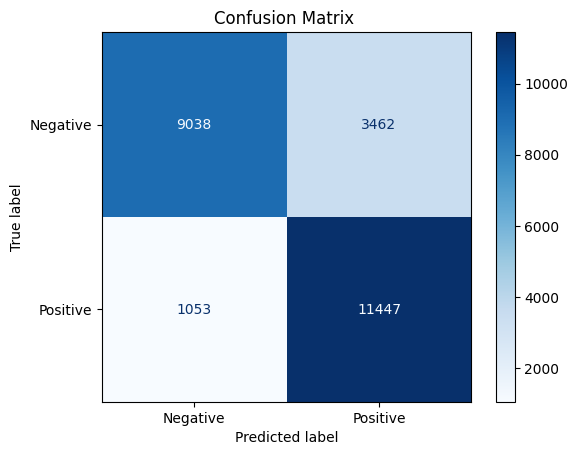

TN=9038  FP=3462  FN=1053  TP=11447


In [31]:
# ====== Confusion matrix ======
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix ")
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

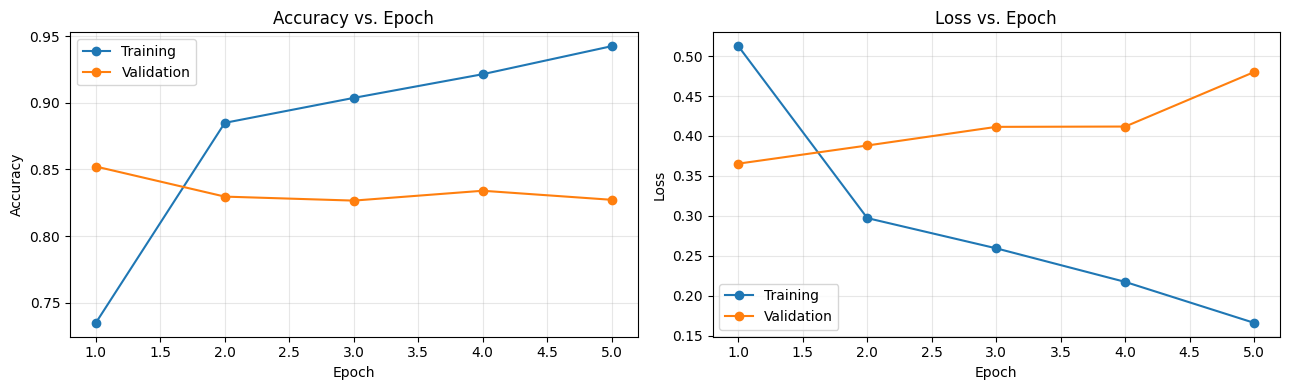

In [26]:
# ====== Accuracy vs Epoch and Loss vs Epoch ======
ep = range(1, len(history.history["accuracy"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(ep, history.history["accuracy"], "o-", label="Training")
ax[0].plot(ep, history.history["val_accuracy"], "o-", label="Validation")
ax[0].set_title("Accuracy vs. Epoch"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Accuracy"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(ep, history.history["loss"], "o-", label="Training")
ax[1].plot(ep, history.history["val_loss"], "o-", label="Validation")
ax[1].set_title("Loss vs. Epoch"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss"); ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

## PART D: SENTIMENT PREDICTION AND EXPERIMENT MANAGEMENT

In [27]:
# Uses the SAME cleaning, vocabulary and padding as training
def predict_sentiment(text):
    seq = pad_sequences([encode(tokenize(text))], maxlen=MAX_LEN,
                        padding="post", truncating="post", value=PAD)
    prob = float(model.predict(seq, verbose=0)[0][0])
    return ("Positive" if prob >= 0.5 else "Negative"), prob

samples = [
    ("This movie was fantastic! The acting was brilliant and the story kept me hooked.", "Positive"),
    ("An absolute masterpiece. I loved every minute of it.", "Positive"),
    ("A heartwarming film with wonderful performances and a beautiful ending.", "Positive"),
    ("Terrible movie. The plot was boring and the acting was awful.", "Negative"),
    ("I wasted two hours of my life. Worst film I have ever seen.", "Negative"),
    ("The script was weak, the characters were dull and I wanted to leave halfway.", "Negative"),
    ("The movie was not good at all.", "Negative"),            # negation test
    ("It started slowly but became a really great and moving film.", "Positive"),  # mixed context
]

rows = []
for text, expected in samples:
    pred, prob = predict_sentiment(text)
    rows.append({"Review": text, "Expected": expected, "Predicted": pred,
                 "P(Positive)": round(prob, 3), "Correct": "Yes" if pred == expected else "No"})

res = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 70)
display(res)
print(f"\nCorrect predictions: {(res.Correct == 'Yes').sum()} / {len(res)}")

,Review,Expected,Predicted,P(Positive),Correct
0,This movie was fantastic! The acting was brilliant and the story k...,Positive,Positive,0.984,Yes
1,An absolute masterpiece. I loved every minute of it.,Positive,Positive,0.951,Yes
2,A heartwarming film with wonderful performances and a beautiful en...,Positive,Positive,0.985,Yes
3,Terrible movie. The plot was boring and the acting was awful.,Negative,Negative,0.005,Yes
4,I wasted two hours of my life. Worst film I have ever seen.,Negative,Negative,0.171,Yes
5,"The script was weak, the characters were dull and I wanted to leav...",Negative,Negative,0.028,Yes
6,The movie was not good at all.,Negative,Positive,0.633,No
7,It started slowly but became a really great and moving film.,Positive,Positive,0.906,Yes



Correct predictions: 7 / 8


In [28]:
# Try your own review
my_review = "The cinematography was stunning and the soundtrack was amazing."
print(my_review, "->", predict_sentiment(my_review))

The cinematography was stunning and the soundtrack was amazing. -> ('Positive', 0.9032065272331238)


### Observations (edit after running)
- The model reaches roughly **84–88% test accuracy** after 5 epochs on IMDB (your numbers may vary slightly).
- Clearly positive/negative reviews with strong sentiment words are classified correctly with high confidence.
- Negation ("not good") and mixed-sentiment sentences are harder; probabilities close to 0.5 indicate uncertainty.
- Words outside the 10,000-word vocabulary become `<UNK>`, which can reduce accuracy.
- Training accuracy rising while validation accuracy flattens/drops indicates overfitting; dropout and fewer epochs help.

### Uploading the notebook to GitHub
1. Colab: **File → Save a copy in GitHub** (sign in and choose a repository), **or**
2. Download via **File → Download → Download .ipynb**, then on github.com open your repo → **Add file → Upload files** → commit.
3. Add the repository link in your record.